Importo librerias:

# Recolección de Datos

##Conectar Drive para cargar archivos disponibles en el path y concatenarlos

In [2]:
import pandas as pd
import os
from gspread_dataframe import set_with_dataframe
from google.colab import drive
from google.auth import default
from oauth2client.service_account import ServiceAccountCredentials

drive.mount('/content/drive')

folder_path = "/content/drive/Shared drives/DatasSOMI_Flota/2025/"
excel_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

dfs = []
for excel_file in excel_files:
    file_path = os.path.join(folder_path, excel_file)
    df = pd.read_excel(file_path, header=1, engine='openpyxl')
    dfs.append(df)
    print(f"Loaded {excel_file}")

dfMtto = pd.concat(dfs, ignore_index=True)
dfMtto = dfMtto.dropna(axis=1, how='all', inplace=False)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded SabanaEne2025.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded SabanaFeb2025.xlsx
Loaded SabanaMar2025.xlsx


...

Loaded SabanaMay2025.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded SabanaAbr2025.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded SabanaJun2025.xlsx


## Anonimización de datos con tablas de equivalencia

In [3]:
# leo las tablas para anonimizar

sheet_id = "1YQEFQr75-ZM0JVi1a8cDybKj9ReIxopFzPloCOrenlU"
sheet_falla = "Falla"
sheet_cliente = "Cliente"
sheet_reque = "Reque"

urlf = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_falla}"
urlc = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_cliente}"
urlr = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_reque}"


dffalla = pd.read_csv(urlf)
dfcliente = pd.read_csv(urlc)
dfreque = pd.read_csv(urlr)

# con Merge uno las tablas con su equivalente

dfMttoA = pd.merge(
    dfMtto,
    dffalla,
    how="left",
    on="Tipo Falla"
)

dfMttoA = pd.merge(
    dfMttoA,
    dfcliente,
    how="left",
    on="Patio"
)

dfMttoA = pd.merge(
    dfMttoA,
    dfreque,
    how="left",
    on="Requerimiento Soporte"
)

# Quito las columnas anonimizadas

dfMttoA.drop(columns=['Tipo Falla', 'Patio', 'Requerimiento Soporte', 'Equipo Bus', 'Equipo CC', 'Ubicación Equipo CC'], inplace=True)

dfMttoA.columns


Index(['Ticket', 'Tipo', 'Servicio', 'Cola', 'Fecha Creación', 'Mes Creación',
       'Fecha Resuelto', 'Fecha Cierre', 'Nota Cierre', 'Estado',
       'Nombre Cliente', 'Asunto', 'Tiempo Nuevo - Fin de Viaje (min)',
       'Tiempo Nuevo - Dispositivo Disponibie (min)',
       'Contador Pendiente Disponibilidad', 'Contador en Espera de Aprobacion',
       'Contador Disponible', 'Fecha Verificando Disponibilidad',
       'Fecha Primer Progreso', 'Fecha Ultimo Progreso',
       'Fecha Espera de Aprobación', 'Fecha Pendiente Disponibilidad',
       'Fecha Asignado a Campo', 'Tiempo en Para Evaluación (seg)', 'Placa',
       'Estado Vinculación', 'Tipo Flota', 'TSF', 'ID Equipo',
       'Categoria Ticket', 'Ubicacion Zona SIRCI', 'ID Movil',
       'Afectación Servicios', 'Seguimiento', 'Quien Gestiona Buses',
       'Descripción', 'Número Cotización', 'Número Orden de Compra',
       'Intervención', 'Motivo No Intervención', 'Tipo Atención',
       'Mala Manipulación', 'Cambio Parte', 'IP

## Estandarizar nombres de columnas (sin espacios ni caracteres especiales).

In [4]:
import re
import unicodedata

#función para estandatrizar nombres de columnas:

def standardize_column_names(df):

    def clean_name(name):

        name = str(name)
        name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
        name = name.lower()
        name = re.sub(r'[^a-z0-9]', '_', name)
        name = re.sub(r'_+', '_', name)
        name = name.strip('_')

        return name

    # diccionario con los nombre originales para estandarizar
    new_columns = {col: clean_name(col) for col in df.columns}

    # Renombrar
    df = df.rename(columns=new_columns)

    return df

df = standardize_column_names(dfMttoA)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148135 entries, 0 to 148134
Data columns (total 58 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   ticket                                   148135 non-null  int64         
 1   tipo                                     148135 non-null  object        
 2   servicio                                 148135 non-null  object        
 3   cola                                     148135 non-null  object        
 4   fecha_creacion                           148135 non-null  datetime64[ns]
 5   mes_creacion                             148135 non-null  object        
 6   fecha_resuelto                           118011 non-null  datetime64[ns]
 7   fecha_cierre                             101617 non-null  datetime64[ns]
 8   nota_cierre                              120413 non-null  object        
 9   estado                    

## Filtrado de los registros que no correspondían a eventos de mantenimiento

In [5]:
# filtro los casos que No corresponden a mantenimiento, para NO incluirlos en el dataset
dfMtto = df.query("clasifica_falla != 'NO CLASIFICA' & clasifica_falla != 'NO CORRESPON REPORT' & clasifica_falla != 'NO ATRIBUIBLE' & cola != 'CES::REPOSICION DE ALMACEN SATELITE BUSES'").reset_index(drop=True)
dfMtto = dfMtto[~dfMtto['id_movil'].str.endswith('ALL')]

# dejo solo las columnas que aportan valor
dfMtto = dfMtto[['ticket',
          'fecha_creacion',
         'servicio',
         'cola',
         'id_movil',
         'quien_gestiona_buses',
         'cambio_parte',
         'partes_buses',
         'clasifica_falla',
         'falla',
         'equipo',
         'clientebd',
         'reqsp']]

# Análisis Exploratorio de Datos (EDA)

In [6]:
dfMtto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90078 entries, 0 to 90230
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ticket                90078 non-null  int64         
 1   fecha_creacion        90078 non-null  datetime64[ns]
 2   servicio              90078 non-null  object        
 3   cola                  90078 non-null  object        
 4   id_movil              90078 non-null  object        
 5   quien_gestiona_buses  89838 non-null  object        
 6   cambio_parte          90078 non-null  object        
 7   partes_buses          22267 non-null  object        
 8   clasifica_falla       90078 non-null  object        
 9   falla                 90078 non-null  object        
 10  equipo                90078 non-null  object        
 11  clientebd             90078 non-null  object        
 12  reqsp                 89816 non-null  object        
dtypes: datetime64[ns](1),

In [7]:
print(dfMtto['clasifica_falla'].value_counts())

clasifica_falla
ATRIBUIBLE         38252
NO FALLA           37738
MTTO PREVENTIVO    14088
Name: count, dtype: int64


## Top 10 Fallas

/tmp/ipython-input-4178195773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top10_fallas.index, y=top10_fallas.values, palette="viridis")


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

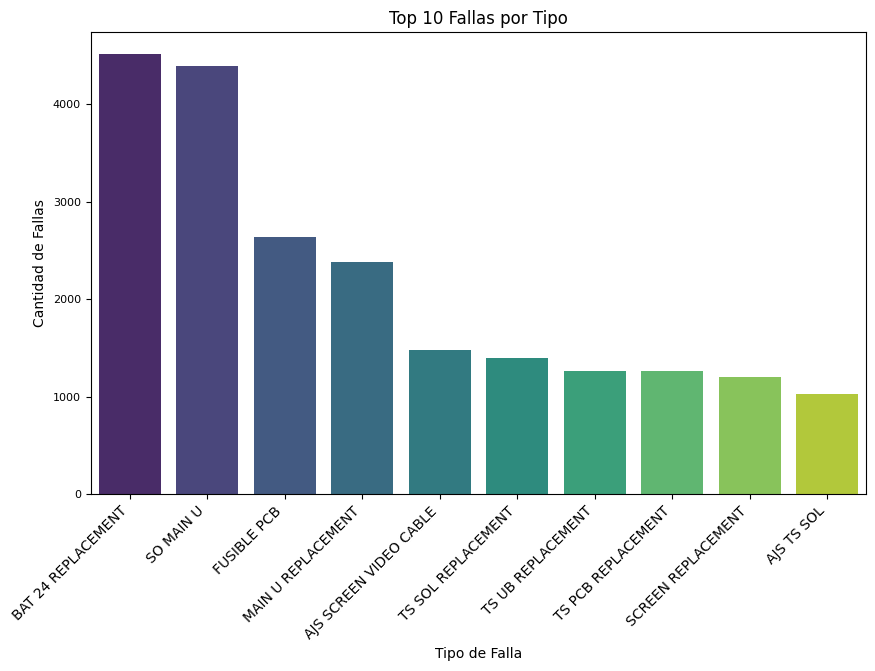

In [8]:
#Grafica Fallas por tipo top10:

import matplotlib.pyplot as plt
import seaborn as sns

#filtro solo Fallas reales
dfMttoF = dfMtto[dfMtto['clasifica_falla'] == 'ATRIBUIBLE']

top10_fallas = dfMttoF['falla'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_fallas.index, y=top10_fallas.values, palette="viridis")
plt.title('Top 10 Fallas por Tipo')
plt.xlabel('Tipo de Falla')
plt.ylabel('Cantidad de Fallas')

plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotar y ajustar la alineación
plt.yticks(fontsize=8)

plt

# Grafica sectores fallas

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

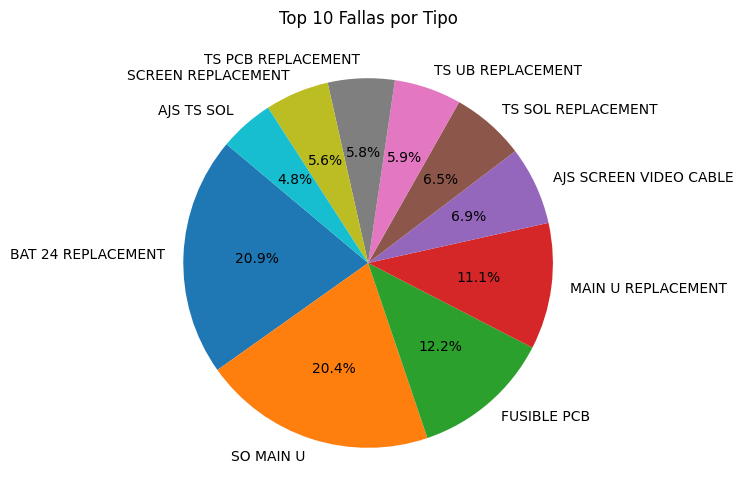

In [9]:
#Grafica Sectores distribución porcentual de fallas:

top10Fallas = dfMttoF['falla'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.pie(top10_fallas.values, labels=top10_fallas.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Fallas por Tipo')
plt

/tmp/ipython-input-2240394533.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top10_Cliente.index, y=top10_Cliente.values, palette="viridis")


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

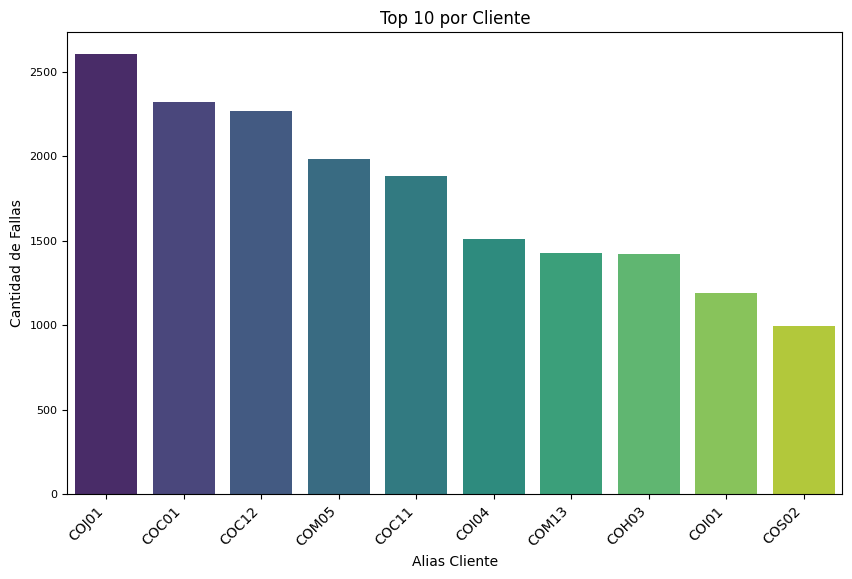

In [10]:
#Grafica por Cliente top10:

# Seleccionar Top 10
top10_Cliente = dfMttoF['clientebd'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_Cliente.index, y=top10_Cliente.values, palette="viridis")
plt.title('Top 10 por Cliente')
plt.xlabel('Alias Cliente')
plt.ylabel('Cantidad de Fallas')

plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotar y ajustar la alineación
plt.yticks(fontsize=8)

plt

##Evolución de los principales tipos de requerimientos a lo largo del primer semestre de 2025

/tmp/ipython-input-476472587.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfMttoF['fecha_creacion'] = pd.to_datetime(dfMttoF['fecha_creacion'])
/tmp/ipython-input-476472587.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfMttoF['Mes'] = dfMttoF['fecha_creacion'].dt.to_period('M').astype(str)


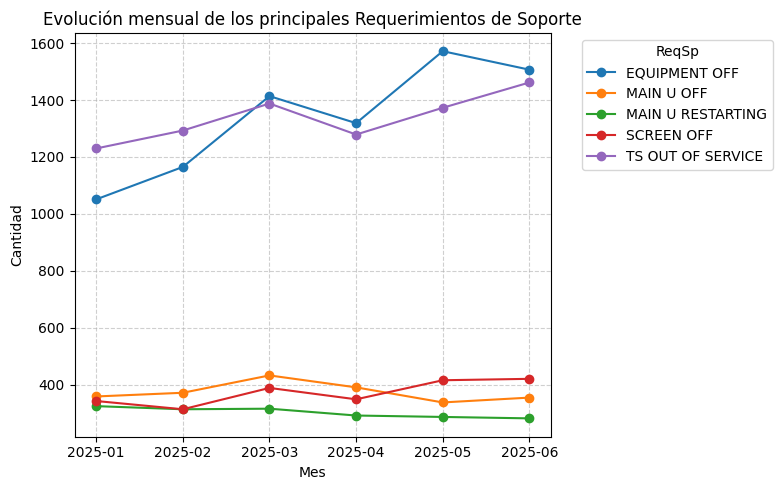

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que 'fecha_creacion' sea datetime
dfMttoF['fecha_creacion'] = pd.to_datetime(dfMttoF['fecha_creacion'])

# columna 'Mes' en formato YYYY-MM
dfMttoF['Mes'] = dfMttoF['fecha_creacion'].dt.to_period('M').astype(str)

df_agg = (
    dfMttoF.groupby(['Mes', 'reqsp'])
            .size()
            .reset_index(name='Cantidad')
)

# Seleccionar Top 5

top_req = (
    df_agg.groupby('reqsp')['Cantidad']
          .sum()
          .nlargest(5)
          .index
)

df_top = df_agg[df_agg['reqsp'].isin(top_req)]

# Pivotear para graficar
df_pivot = df_top.pivot(index='Mes', columns='reqsp', values='Cantidad').fillna(0)

# Grafica
plt.figure(figsize=(8, 5))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], marker='o', label=col)

plt.title('Evolución mensual de los principales Requerimientos de Soporte')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.legend(title='ReqSp', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##**DESARROLLO DEL MODELO PREDICTIVO**

#Preparación de los datos para el modelado de supervivencia, Feature Engineering

# Variabales clave: event y duration

In [12]:
import numpy as np

#función para crear event y duration
def preparar_supervivencia_mtto(dff):

    dff = dff.copy()
    dff = dff.sort_values(['id_movil', 'fecha_creacion'])
    dff['fecha_creacion'] = pd.to_datetime(dff['fecha_creacion'])

    # Calcular ventana de observación
    dias_observacion = (dff['fecha_creacion'].max() - dff['fecha_creacion'].min()).days
    print(f"Ventana de observación: {dias_observacion} días")

    #asegurar fallas reales
    df_fallas = (
        dff[dff['clasifica_falla'].str.upper() == 'ATRIBUIBLE']
        [['id_movil', 'fecha_creacion']]
        .rename(columns={'fecha_creacion': 'fecha_prox_falla'})
    )

    # Merge asof para encontrar la próxima falla
    dff = pd.merge_asof(
        dff.sort_values('fecha_creacion'),
        df_fallas.sort_values('fecha_prox_falla'),
        by='id_movil',
        left_on='fecha_creacion',
        right_on='fecha_prox_falla',
        direction='forward',
        allow_exact_matches=False
    )

    # Calcular duración (días hasta próxima falla)
    dff['duration'] = (dff['fecha_prox_falla'] - dff['fecha_creacion']).dt.days
    dff['duration'] = dff['duration'].fillna(dias_observacion)

    # Definir evento: 1 si es falla real (ATRIBUIBLE)
    dff['event'] = np.where(dff['clasifica_falla'].str.upper() == 'ATRIBUIBLE', 1, 0)

    # Marcar último registro de cada bus como censurado (event = 0)
    idx_ultimos = dff.groupby('id_movil')['fecha_creacion'].idxmax()
    dff.loc[idx_ultimos, 'event'] = 0

    return dff


df_features = dfMtto.copy()
df_features = preparar_supervivencia_mtto(df_features)
df_features.info()

Ventana de observación: 180 días
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90078 entries, 0 to 90077
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ticket                90078 non-null  int64         
 1   fecha_creacion        90078 non-null  datetime64[ns]
 2   servicio              90078 non-null  object        
 3   cola                  90078 non-null  object        
 4   id_movil              90078 non-null  object        
 5   quien_gestiona_buses  89838 non-null  object        
 6   cambio_parte          90078 non-null  object        
 7   partes_buses          22267 non-null  object        
 8   clasifica_falla       90078 non-null  object        
 9   falla                 90078 non-null  object        
 10  equipo                90078 non-null  object        
 11  clientebd             90078 non-null  object        
 12  reqsp                 89816 non-null  obj

# Variabales Temporales

Variables tiempo mes, dia, semana

In [13]:
# Variables temporales básicas
df_features['mes'] = df_features['fecha_creacion'].dt.month
df_features['semana'] = df_features['fecha_creacion'].dt.isocalendar().week.astype(int)
df_features['dia_semana'] = df_features['fecha_creacion'].dt.dayofweek  # 0=Lunes, 6=Domingo

# Mes (1 a 12)
df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes"] / 12)
df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes"] / 12)

# Semana del año (1 a 52)
df_features["semana_sin"] = np.sin(2 * np.pi * df_features["semana"] / 52)
df_features["semana_cos"] = np.cos(2 * np.pi * df_features["semana"] / 52)

# Día de la semana (1 a 7)
df_features["dia_semana_sin"] = np.sin(2 * np.pi * df_features["dia_semana"] / 7)
df_features["dia_semana_cos"] = np.cos(2 * np.pi * df_features["dia_semana"] / 7)

# elimino las columnas redundantes
df_features = df_features.drop(columns=["mes", "semana", "dia_semana"])

Variable dias que pasaron desde el ultimo mantenimiento

In [14]:
# columna que marca fecha sólo si es mantenimiento real
df_features['fecha_mtto_real'] = pd.to_datetime(
    np.where(
        df_features['clasifica_falla'].isin(['ATRIBUIBLE', 'MTTO PREVENTIVO']),
        df_features['fecha_creacion'],
        pd.NaT
    ),
    errors='coerce'
)

# ordenar por id y fecha
df_features = df_features.sort_values(['id_movil', 'fecha_creacion']).reset_index(drop=True)

# inicializar columna con NaT y tipo datetime
df_features['ultima_intervencion'] = pd.Series(pd.NaT, index=df_features.index, dtype='datetime64[ns]')


# Cálculo por grupo de forma segura
for movil, indices in df_features.groupby('id_movil', sort=False).groups.items():
    # slice ordenado por fecha (porque df_features ya está ordenado)
    s = df_features.loc[indices, 'fecha_mtto_real']
    # shift para que la fila actual no vea su propia fecha y ffill para propagar la última conocida
    s_prev = s.shift(1).ffill()
    # asignar respetando los índices originales del DataFrame
    df_features.loc[indices, 'ultima_intervencion'] = s_prev.values


# asegurar dtype datetime
df_features['ultima_intervencion'] = pd.to_datetime(df_features['ultima_intervencion'], errors='coerce')

# cálculo de días desde la última intervención real previa
df_features['dias_desde_ultimo_mtto'] = (df_features['fecha_creacion'] - df_features['ultima_intervencion']).dt.days

# regla: si nunca tuvo mantenimiento previo rellenar con 180
df_features['dias_desde_ultimo_mtto'] = df_features['dias_desde_ultimo_mtto'].fillna(180)

In [15]:
df_features.head()

,ticket,fecha_creacion,servicio,cola,id_movil,quien_gestiona_buses,cambio_parte,partes_buses,clasifica_falla,falla,...,event,mes_sin,mes_cos,semana_sin,semana_cos,dia_semana_sin,dia_semana_cos,fecha_mtto_real,ultima_intervencion,dias_desde_ultimo_mtto
0,21948209,2025-01-31 02:08:06,BUS ZONAL::CONTROL DE FLOTA::MANTENIMIENTO PRE...,RB::MANTENIMIENTO PREVENTIVO,102018,1031170576,NO,NaN,MTTO PREVENTIVO,MTTO PREVENTIVO,...,0,0.500000,0.866025,0.568065,0.822984,-0.433884,-0.900969,2025-01-31 02:08:06,NaT,180.0
1,21962505,2025-02-09 07:27:30,BUS ZONAL::CONTROL DE FLOTA::EQUIPOS DE CONTRO...,RB::SOPORTE BUS ZONAL,102018,1032436112,NO,NaN,ATRIBUIBLE,AJS GPS GPRS CNT,...,1,0.866025,0.500000,0.663123,0.748511,-0.781831,0.623490,2025-02-09 07:27:30,2025-01-31 02:08:06,9.0
2,21962630,2025-02-09 08:58:12,BUS ZONAL::CONTROL DE FLOTA::COMUNICACION DE V...,RB::SOPORTE BUS ZONAL,102018,1032436112,NO,NaN,ATRIBUIBLE,AJS DR MIC CNT,...,1,0.866025,0.500000,0.663123,0.748511,-0.781831,0.623490,2025-02-09 08:58:12,2025-02-09 07:27:30,0.0
3,21964145,2025-02-10 12:09:31,BUS ZONAL::CONTROL DE FLOTA::EQUIPOS DE CONTRO...,RB::SOPORTE BUS ZONAL,102018,1015399388,NO,NaN,ATRIBUIBLE,AJS SCREEN VIDEO CABLE,...,1,0.866025,0.500000,0.748511,0.663123,0.000000,1.000000,2025-02-10 12:09:31,2025-02-09 08:58:12,1.0
4,22054555,2025-04-19 02:09:45,BUS ZONAL::CONTROL DE FLOTA::MANTENIMIENTO RUT...,RB::MANTENIMIENTO PREVENTIVO,102018,1031170576,NO,NaN,MTTO PREVENTIVO,MTTO PREVENTIVO,...,0,0.866025,-0.500000,0.935016,-0.354605,-0.974928,-0.222521,2025-04-19 02:09:45,2025-02-10 12:09:31,67.0


Conteos en ventanas usando searchsorted

In [16]:
# Asegurar formato y orden
df_features['fecha_creacion'] = pd.to_datetime(df_features['fecha_creacion'], errors='coerce')
df_features = df_features.sort_values(['id_movil','fecha_creacion']).reset_index(drop=True)

# Inicializar columnas
df_features['fallas_atribuibles_30d'] = 0
df_features['fallas_atribuibles_7d'] = 0
df_features['no_falla_7d'] = 0

# Ventanas
w30 = 30
w7  = 7

# Procesar por grupo (id_movil)
for movil, idx in df_features.groupby('id_movil', sort=False).groups.items():
    group = df_features.loc[idx]                      # slice (preserva índices originales)
    dates = group['fecha_creacion'].to_numpy(dtype='datetime64[ns]')
    # arrays de fechas para cada tipo de interés
    dates_atr = dates[group['clasifica_falla'].to_numpy() == 'ATRIBUIBLE']
    dates_no  = dates[group['clasifica_falla'].to_numpy() == 'NO FALLA']

    # Prealocar listas
    c30 = np.zeros(len(dates), dtype=int)
    c7_atr = np.zeros(len(dates), dtype=int)
    c7_no  = np.zeros(len(dates), dtype=int)

    # Si hay eventos ATRIBUIBLE, usamos searchsorted sobre dates_atr
    if dates_atr.size > 0:
        # for each date d, count event_dates in [d-window, d)
        for i, d in enumerate(dates):
            left = np.searchsorted(dates_atr, d - np.timedelta64(w30, 'D'), side='left')
            right = np.searchsorted(dates_atr, d, side='left')  # exclude same-day event (strictly before)
            c30[i] = right - left

            left7 = np.searchsorted(dates_atr, d - np.timedelta64(w7, 'D'), side='left')
            right7 = np.searchsorted(dates_atr, d, side='left')
            c7_atr[i] = right7 - left7

    # If there are any NO FALLA events
    if dates_no.size > 0:
        for i, d in enumerate(dates):
            left_no = np.searchsorted(dates_no, d - np.timedelta64(w7, 'D'), side='left')
            right_no = np.searchsorted(dates_no, d, side='left')
            c7_no[i] = right_no - left_no

    # Assign back to original dataframe using the group's index
    df_features.loc[group.index, 'fallas_atribuibles_30d'] = c30
    df_features.loc[group.index, 'fallas_atribuibles_7d']  = c7_atr
    df_features.loc[group.index, 'no_falla_7d']           = c7_no

# Ratio seguro (evitando división por cero)
df_features['ratio_fallas_7d'] = (
    df_features['fallas_atribuibles_7d'] /
    (df_features['fallas_atribuibles_7d'] + df_features['no_falla_7d'])
).replace([np.inf, -np.inf], 0).fillna(0)

# Verificación de lo creado
print("Resumen de nuevas features:")
display(df_features[['id_movil','fecha_creacion','clasifica_falla',
                     'fallas_atribuibles_30d','fallas_atribuibles_7d','no_falla_7d','ratio_fallas_7d']].head(20))

print("\nEstadísticas:")
display(df_features[['fallas_atribuibles_30d','fallas_atribuibles_7d','no_falla_7d','ratio_fallas_7d']].describe())

Resumen de nuevas features:


,id_movil,fecha_creacion,clasifica_falla,fallas_atribuibles_30d,fallas_atribuibles_7d,no_falla_7d,ratio_fallas_7d
0,102018,2025-01-31 02:08:06,MTTO PREVENTIVO,0,0,0,0.000000
1,102018,2025-02-09 07:27:30,ATRIBUIBLE,0,0,0,0.000000
2,102018,2025-02-09 08:58:12,ATRIBUIBLE,1,1,0,1.000000
3,102018,2025-02-10 12:09:31,ATRIBUIBLE,2,2,0,1.000000
4,102018,2025-04-19 02:09:45,MTTO PREVENTIVO,0,0,0,0.000000
5,102018,2025-04-21 06:11:33,ATRIBUIBLE,0,0,0,0.000000
6,102018,2025-05-21 15:28:05,ATRIBUIBLE,0,0,0,0.000000
7,102018,2025-06-01 04:48:28,NO FALLA,1,0,0,0.000000
8,102019,2025-01-31 08:48:47,NO FALLA,0,0,0,0.000000
9,102019,2025-02-05 09:37:01,ATRIBUIBLE,0,0,1,0.000000



Estadísticas:


,fallas_atribuibles_30d,fallas_atribuibles_7d,no_falla_7d,ratio_fallas_7d
count,90078.000000,90078.000000,90078.000000,90078.000000
mean,0.952841,0.337374,0.358245,0.193455
std,1.404468,0.717446,0.753508,0.367557
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000
max,14.000000,12.000000,8.000000,1.000000


In [17]:
# Ordenar el dataframe por fecha_creacion
df_features = df_features.sort_values(by='fecha_creacion').reset_index(drop=True)

df_features.head(20)

,ticket,fecha_creacion,servicio,cola,id_movil,quien_gestiona_buses,cambio_parte,partes_buses,clasifica_falla,falla,...,semana_cos,dia_semana_sin,dia_semana_cos,fecha_mtto_real,ultima_intervencion,dias_desde_ultimo_mtto,fallas_atribuibles_30d,fallas_atribuibles_7d,no_falla_7d,ratio_fallas_7d
0,21911049,2025-01-01 00:13:52,BUS ZONAL::RECAUDO EN FLOTA::CONTROL DE ACCESO...,RB::SOPORTE BUS ZONAL,504269,1032398899,NO,NaN,ATRIBUIBLE,AJS TS TRI,...,0.992709,0.974928,-0.222521,2025-01-01 00:13:52,NaT,180.0,0,0,0,0.0
1,21911050,2025-01-01 00:40:06,BUS ZONAL::CONTROL DE FLOTA::MANTENIMIENTO RUT...,RB::MANTENIMIENTO PREVENTIVO,407218,1118807133,NO,NaN,MTTO PREVENTIVO,MTTO PREVENTIVO,...,0.992709,0.974928,-0.222521,2025-01-01 00:40:06,NaT,180.0,0,0,0,0.0
2,21911051,2025-01-01 01:37:41,BUS ZONAL::CONTROL DE FLOTA::EQUIPOS DE CONTRO...,RB::SOPORTE BUS ZONAL,807409,1001328002,NO,NaN,NO FALLA,NO FALLA,...,0.992709,0.974928,-0.222521,NaT,NaT,180.0,0,0,0,0.0
3,21911052,2025-01-01 01:40:07,BUS ZONAL::CONTROL DE FLOTA::EQUIPOS DE CONTRO...,RB::SOPORTE BUS ZONAL,807030,1001328002,NO,NaN,NO FALLA,NO FALLA,...,0.992709,0.974928,-0.222521,NaT,NaT,180.0,0,0,0,0.0
4,21911053,2025-01-01 01:42:43,BUS ZONAL::RECAUDO EN FLOTA::CONTROL DE ACCESO...,RB::SOPORTE BUS ZONAL,102259,1055553957,NO,NaN,NO FALLA,NO FALLA,...,0.992709,0.974928,-0.222521,NaT,NaT,180.0,0,0,0,0.0
5,21911054,2025-01-01 01:43:33,BUS ZONAL::CONTROL DE FLOTA::EQUIPOS DE CONTRO...,RB::SOPORTE BUS ZONAL,807166,1024556241,NO,NaN,NO FALLA,NO FALLA,...,0.992709,0.974928,-0.222521,NaT,NaT,180.0,0,0,0,0.0
6,21911055,2025-01-01 02:16:52,BUS ZONAL::RECAUDO EN FLOTA::CONTROL DE ACCESO...,RB::SOPORTE BUS ZONAL,107143,1030554973,SI,TAPA CAUCHO TRIPODE TORNIQUETE::I30808550,ATRIBUIBLE,TRI TS REPLACEMENT,...,0.992709,0.974928,-0.222521,2025-01-01 02:16:52,NaT,180.0,0,0,0,0.0
7,21911056,2025-01-01 02:32:05,BUS ZONAL::CONTROL DE FLOTA::SISTEMA ELECTRICO...,RB::SOPORTE BUS ZONAL,937207,1033724318,SI,BATERIA AUXILIAR 24V::I20808051,ATRIBUIBLE,BAT 24 REPLACEMENT,...,0.992709,0.974928,-0.222521,2025-01-01 02:32:05,NaT,180.0,0,0,0,0.0
8,21911057,2025-01-01 02:48:11,BUS TRONCAL::CONTROL DE FLOTA::EQUIPOS DE CONT...,RB::SOPORTE BUS TRONCAL,U10525,1022973259,NO,NaN,NO FALLA,NO FALLA,...,0.992709,0.974928,-0.222521,NaT,NaT,180.0,0,0,0,0.0
9,21911058,2025-01-01 02:51:38,BUS TRONCAL::CONTROL DE FLOTA::EQUIPOS DE CONT...,RB::SOPORTE BUS TRONCAL,U10406,1022973259,NO,NaN,ATRIBUIBLE,AJS SCREEN VIDEO CABLE,...,0.992709,0.974928,-0.222521,2025-01-01 02:51:38,NaT,180.0,0,0,0,0.0


# Variabales Categoricas

In [18]:
#Info del df_features

df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90078 entries, 0 to 90077
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ticket                  90078 non-null  int64         
 1   fecha_creacion          90078 non-null  datetime64[ns]
 2   servicio                90078 non-null  object        
 3   cola                    90078 non-null  object        
 4   id_movil                90078 non-null  object        
 5   quien_gestiona_buses    89838 non-null  object        
 6   cambio_parte            90078 non-null  object        
 7   partes_buses            22267 non-null  object        
 8   clasifica_falla         90078 non-null  object        
 9   falla                   90078 non-null  object        
 10  equipo                  90078 non-null  object        
 11  clientebd               90078 non-null  object        
 12  reqsp                   89816 non-null  object

In [19]:
# Codifico solo las columnas categoricas que aportan valor al modelo

from sklearn.preprocessing import LabelEncoder

# Copia del dataframe para no afectar el df con features
df_encoded = df_features.copy()

# variables categoricas que me interesan para el modelo
cat_cols = ['cambio_parte', 'servicio', 'partes_buses', 'falla', 'equipo', 'clientebd', 'reqsp']

# Codificar columnas categóricas
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  # guardar el encoder por si se requiere luego


Df final para el modelo

In [20]:
# variables categoricas que NO me interesan para el modelo
cols_to_drop = ['ticket', 'fecha_creacion', 'cola', 'Mes', 'quien_gestiona_buses', 'clasifica_falla', 'fecha_prox_falla', 'fecha_mtto_real', 'ultima_intervencion']

df_final = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_final.head()

,servicio,id_movil,cambio_parte,partes_buses,falla,equipo,clientebd,reqsp,duration,event,...,mes_cos,semana_sin,semana_cos,dia_semana_sin,dia_semana_cos,dias_desde_ultimo_mtto,fallas_atribuibles_30d,fallas_atribuibles_7d,no_falla_7d,ratio_fallas_7d
0,66,504269,0,1041,64,26,28,65,84.0,1,...,0.866025,0.120537,0.992709,0.974928,-0.222521,180.0,0,0,0,0.0
1,62,407218,0,1041,104,18,20,35,7.0,0,...,0.866025,0.120537,0.992709,0.974928,-0.222521,180.0,0,0,0,0.0
2,59,807409,0,1041,112,18,49,44,5.0,0,...,0.866025,0.120537,0.992709,0.974928,-0.222521,180.0,0,0,0,0.0
3,59,807030,0,1041,112,18,49,61,1.0,0,...,0.866025,0.120537,0.992709,0.974928,-0.222521,180.0,0,0,0,0.0
4,66,102259,0,1041,112,18,9,65,35.0,0,...,0.866025,0.120537,0.992709,0.974928,-0.222521,180.0,0,0,0,0.0


# Modelo Cox Net

Preparación de la Variable Dependiente 'y'

In [21]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.6 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.5
    Uninstalling osqp-1.0.5:
      Successfully uninstalled osqp-1.0.5


In [22]:
#Definir los nombres de las columnas de tiempo y evento

from sksurv.util import Surv

TIEMPO_COL = 'duration'
EVENTO_COL = 'event'

# 2. Crear el array estructurado 'y'
# La función Surv se encarga de formatear el array correctamente
y = Surv.from_arrays(
    event=df_final[EVENTO_COL].astype(bool),  # Asegúrate de que 'event' sea booleano (True/False)
    time=df_final[TIEMPO_COL]
)

print(f"La forma de la variable 'y' es: {y.shape}")
print(f"Tipo de 'y': {type(y)}")
print("Primeras 5 filas de 'y':")
print(y[:5])

La forma de la variable 'y' es: (90078,)
Tipo de 'y': <class 'numpy.ndarray'>
Primeras 5 filas de 'y':
[( True, 84.) (False,  7.) (False,  5.) (False,  1.) (False, 35.)]


Preparación de la Variable independiente 'X'

In [23]:
# Identificar las columnas a excluir
columnas_a_excluir = [TIEMPO_COL, EVENTO_COL, 'id_movil']

# Crear el DataFrame de características 'X'
# Se seleccionan todas las columnas que no están en la lista de exclusión
X = df_final.drop(columns=columnas_a_excluir)

print(f"La forma de la matriz 'X' es: {X.shape}")
print("Primeras 5 filas de 'X':")
print(X.head())

La forma de la matriz 'X' es: (90078, 18)
Primeras 5 filas de 'X':
   servicio  cambio_parte  partes_buses  falla  equipo  clientebd  reqsp  \
0        66             0          1041     64      26         28     65   
1        62             0          1041    104      18         20     35   
2        59             0          1041    112      18         49     44   
3        59             0          1041    112      18         49     61   
4        66             0          1041    112      18          9     65   

   mes_sin   mes_cos  semana_sin  semana_cos  dia_semana_sin  dia_semana_cos  \
0      0.5  0.866025    0.120537    0.992709        0.974928       -0.222521   
1      0.5  0.866025    0.120537    0.992709        0.974928       -0.222521   
2      0.5  0.866025    0.120537    0.992709        0.974928       -0.222521   
3      0.5  0.866025    0.120537    0.992709        0.974928       -0.222521   
4      0.5  0.866025    0.120537    0.992709        0.974928       -0.222521

Entrenar el modelo COXNET

In [24]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Estandarizar las características(Recomendado para modelos penalizados), asegurar que todas las variables tengan la misma escala, lo cual es crítico para la regularización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Inicializar y Entrenar el Modelo Coxnet
# Los parámetros alpha serán determinados automáticamente por el modelo.
coxnet_model = CoxnetSurvivalAnalysis(l1_ratio=0.9, fit_baseline_model=True)
coxnet_model.fit(X_train_scaled, y_train)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9)

Evaluación del Modelo (C-Index)

In [25]:
from sksurv.metrics import concordance_index_censored
import numpy as np

# 1. Obtener la predicción de riesgo (El riesgo es float, esto está bien)
riesgo_predicho = coxnet_model.predict(X_test_scaled)

# 2. Preparación de los datos para la función de evaluación (¡CORRECCIÓN FINAL!)

# El indicador de evento DEBE ser un array booleano simple (True/False)
event_indicator_bool = y_test['event'].astype(bool)

# El tiempo DEBE ser un array de punto flotante simple
event_time_float = y_test['time'].astype(float)

# 3. Calcular el C-Index usando los arrays corregidos
# Argumentos: (event_indicator [bool], event_time [float], estimate [float])
cindex = concordance_index_censored(
    event_indicator_bool,  # Ahora es el tipo bool que la función exige
    event_time_float,      # Ahora es float simple
    riesgo_predicho        # El riesgo predicho (float)
)[0]

print(f"\nÍndice de Concordancia (C-Index) en el conjunto de prueba: {cindex:.4f}")


Índice de Concordancia (C-Index) en el conjunto de prueba: 0.7766


Curva de calibración y BrierScore

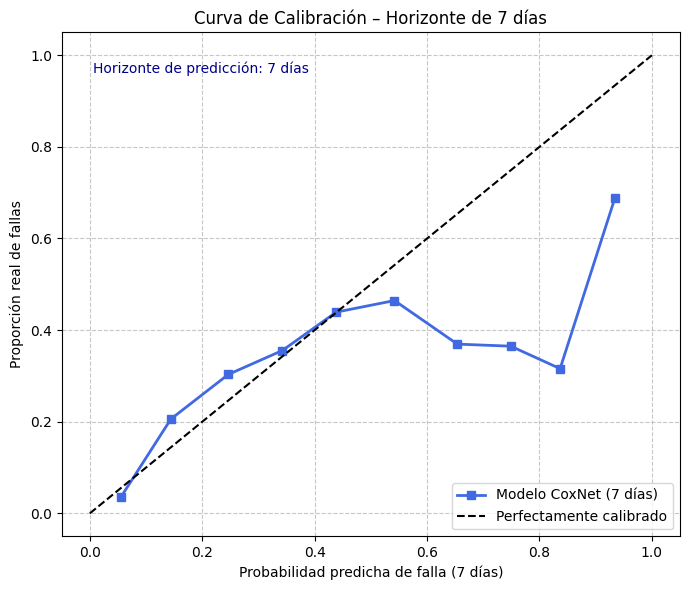

Brier Score a 7 días: 0.1014


In [26]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Definir horizonte de predicción (7 días)
horizonte = 7

# Obtener funciones de supervivencia para cada muestra del test
surv_funcs = coxnet_model.predict_survival_function(X_test_scaled)

# Calcular probabilidad de supervivencia a 7 días
prob_supervivencia_7d = np.array([fn(horizonte) for fn in surv_funcs])

# Convertir a probabilidad de falla en 7 días
prob_falla_7d = 1 - prob_supervivencia_7d

# Extraer tiempos y eventos del array estructurado
eventos = y_test['event']
tiempos = y_test['time']

# Crear variable binaria: falla observada en los próximos 7 días
observado_7d = ((eventos == True) & (tiempos <= horizonte)).astype(int)

# Calcular curva de calibración
fracc_observada, fracc_predicha = calibration_curve(
    observado_7d, prob_falla_7d, n_bins=10, strategy='uniform'
)

# Graficar la curva
plt.figure(figsize=(7,6))
plt.plot(fracc_predicha, fracc_observada, "s-", color="royalblue", linewidth=2, markersize=6, label="Modelo CoxNet (7 días)")
plt.plot([0,1], [0,1], "k--", label="Perfectamente calibrado")
plt.xlabel("Probabilidad predicha de falla (7 días)")
plt.ylabel("Proporción real de fallas")
plt.title("Curva de Calibración – Horizonte de 7 días")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

# Añadir anotación dentro del gráfico
plt.text(0.05, 0.92, f"Horizonte de predicción: {horizonte} días",
         fontsize=10, color="darkblue", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

# Calcular Brier Score a 7 días
brier_7d = brier_score_loss(observado_7d, prob_falla_7d)
print(f"Brier Score a 7 días: {brier_7d:.4f}")

Influencia de las Variables (Coeficientes)

In [27]:
# Extraer la matriz completa de coeficientes
# La matriz tiene forma (n_features, n_alphas)
coef_matrix = coxnet_model.coef_

# Seleccionar la solución final (última columna)
# Usamos [:, -1] para seleccionar todas las filas y la última columna.
# Esta es la solución de coeficientes para el nivel de penalización más bajo o el final del camino de regularización.
final_coefs = coef_matrix[:, -1]

# Crear la Serie de Pandas con los nombres de las columnas (índice 18)
coefs = pd.Series(final_coefs, index=X.columns)

print("Coeficientes del Modelo Cox Penalizado (Solución Final):")
print(coefs.sort_values(ascending=False))

Coeficientes del Modelo Cox Penalizado (Solución Final):
cambio_parte              0.761013
semana_cos                0.237942
semana_sin                0.196685
servicio                  0.179295
fallas_atribuibles_30d    0.153526
equipo                    0.110226
reqsp                     0.097113
partes_buses              0.071914
no_falla_7d               0.054696
dia_semana_sin            0.053897
mes_cos                   0.044544
ratio_fallas_7d           0.029520
mes_sin                   0.000000
fallas_atribuibles_7d     0.000000
dia_semana_cos           -0.006682
dias_desde_ultimo_mtto   -0.048434
clientebd                -0.086850
falla                    -0.442168
dtype: float64


 Función de Supervivencia

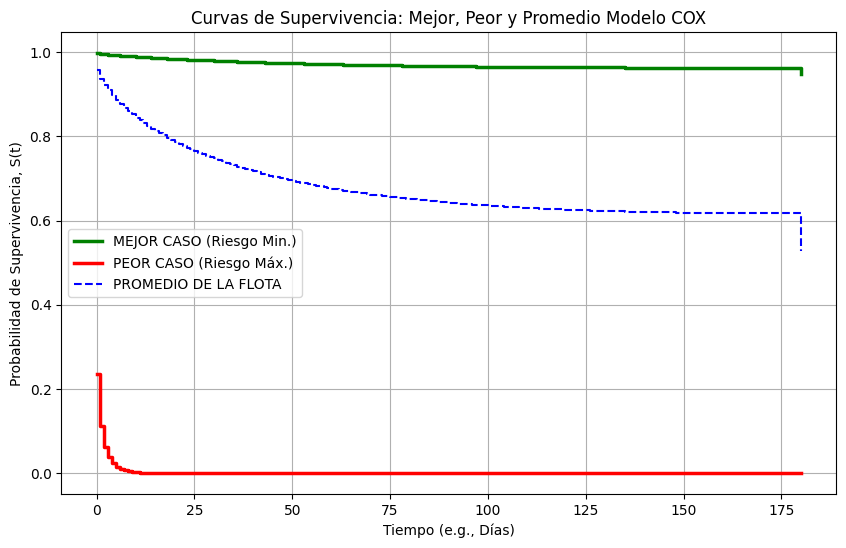

In [28]:
# Calcular el score de riesgo para cada bus en el conjunto de prueba
# El riesgo predicho es lo que determina si un bus es "mejor" o "peor".
riesgo_predicho_test = coxnet_model.predict(X_test_scaled)

# Identificar los índices de los casos extremos

# El riesgo más bajo (MEJOR CASO) es el bus que el modelo predice que fallará MÁS TARDE.
# Se encuentra en el índice donde el riesgo es mínimo (np.argmin).
idx_mejor_caso = np.argmin(riesgo_predicho_test)

# El riesgo más alto (PEOR CASO) es el bus que el modelo predice que fallará MÁS PRONTO.
# Se encuentra en el índice donde el riesgo es máximo (np.argmax).
idx_peor_caso = np.argmax(riesgo_predicho_test)

# Graficar las curvas de Supervivencia

# Curva de Supervivencia del MEJOR y PEOR CASO
indices_a_graficar = [idx_mejor_caso, idx_peor_caso]
etiquetas = ["MEJOR CASO (Riesgo Min.)", "PEOR CASO (Riesgo Máx.)"]
colores = ['g', 'r'] # Verde para mejor, rojo para peor

plt.figure(figsize=(10, 6))

for i, idx in enumerate(indices_a_graficar):
    # Accedemos a la StepFunction almacenada en surv_funcs
    sf = surv_funcs[idx]
    plt.step(sf.x, sf.y, where="post", label=etiquetas[i], color=colores[i], linewidth=2.5)

# Curva de Supervivencia PROMEDIO (Baseline)
# El riesgo promedio se obtiene promediando las funciones de supervivencia.
# Tomamos los puntos de tiempo de la primera curva (asumiendo que son consistentes)
time_points = surv_funcs[0].x

# Calculamos la supervivencia promedio en cada punto de tiempo
survival_prob_mean = np.mean([sf(time_points) for sf in surv_funcs], axis=0)

plt.step(time_points, survival_prob_mean, where="post", label="PROMEDIO DE LA FLOTA", color='b', linestyle='--', linewidth=1.5)


plt.title("Curvas de Supervivencia: Mejor, Peor y Promedio Modelo COX")
plt.xlabel("Tiempo (e.g., Días)")
plt.ylabel("Probabilidad de Supervivencia, S(t)")
plt.legend()
plt.grid(True)
plt.show()

#Comaparar modelos CoxNet VS RSF

In [29]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# Inicializar y entrenar el modelo RSF
# Usaremos hiperparámetros robustos para un entrenamiento estable.
rsf = RandomSurvivalForest(
    n_estimators=100,
    # El modelo RSF NO requiere escalado, pero lo entrenaremos con X_train_scaled para consistencia
    max_features=np.sqrt(X_train_scaled.shape[1]).astype(int),
    min_samples_leaf=20, # Un valor más alto ayuda a evitar el sobreajuste en datos ruidosos
    random_state=42,
    n_jobs=-1
)

# Usamos el conjunto de entrenamiento original (escalado)
rsf.fit(X_train_scaled, y_train)

# Evaluación de RSF
# RSF utiliza el método predict() para devolver el score de riesgo acumulado
rsf_riesgo_predicho = rsf.predict(X_test_scaled)

# Calcular el C-Index para RSF
rsf_cindex = concordance_index_censored(
    y_test['event'].astype(bool),
    y_test['time'].astype(float),
    rsf_riesgo_predicho
)[0]



# Conclusión metrica C-Iindex:

COXNET_CINDEX = 0.7766 # resultado incial CoxNet

print("\n=== C-Index CoxNet vs C-Index RSF ===\n")
print(f"C-Index CoxNet : {COXNET_CINDEX:.4f}")
print(f"C-Index RSF    : {rsf_cindex:.4f}")


=== C-Index CoxNet vs C-Index RSF ===

C-Index CoxNet : 0.7766
C-Index RSF    : 0.8497


Brian Score 7 dias

In [32]:
import pandas as pd
from sklearn.metrics import brier_score_loss
import numpy as np

# Definir horizonte de predicción (7 días)
horizonte = 7

# Obtener funciones de supervivencia para cada muestra del test para RSF
rsf_surv_funcs = rsf.predict_survival_function(X_test_scaled)

# Calcular probabilidad de supervivencia a 7 días para RSF
rsf_prob_supervivencia_7d = np.array([fn(horizonte) for fn in rsf_surv_funcs])

# Convertir a probabilidad de falla en 7 días para RSF
rsf_prob_falla_7d = 1 - rsf_prob_supervivencia_7d

# Extraer tiempos y eventos del array estructurado (y_test was already defined)
eventos = y_test['event']
tiempos = y_test['time']

# Crear variable binaria: falla observada en los próximos 7 días (already created in cell 9foH-dSVuuQd)
observado_7d = ((eventos == True) & (tiempos <= horizonte)).astype(int)

# Calcular Brier Score a 7 días para RSF
brier_rsf = brier_score_loss(observado_7d, rsf_prob_falla_7d)

# Resultados de los modelos
resultados = {
    "Modelo": ["CoxNet", "Random Survival Forest"],
    "C-Index": [COXNET_CINDEX, rsf_cindex],
    "Brier Score (7 días)": [brier_7d, brier_rsf]
}

tabla_resultados = pd.DataFrame(resultados)

# Redondear para presentación
tabla_resultados["C-Index"] = tabla_resultados["C-Index"].round(4)
tabla_resultados["Brier Score (7 días)"] = tabla_resultados["Brier Score (7 días)"].round(4)

print("\n Resultados comparativos:")
print(tabla_resultados.to_string(index=False))


 Resultados comparativos:
                Modelo  C-Index  Brier Score (7 días)
                CoxNet   0.7766                0.1014
Random Survival Forest   0.8497                0.0880


Curva de Calibración – CoxNet vs RSF (Horizonte: 7 días)

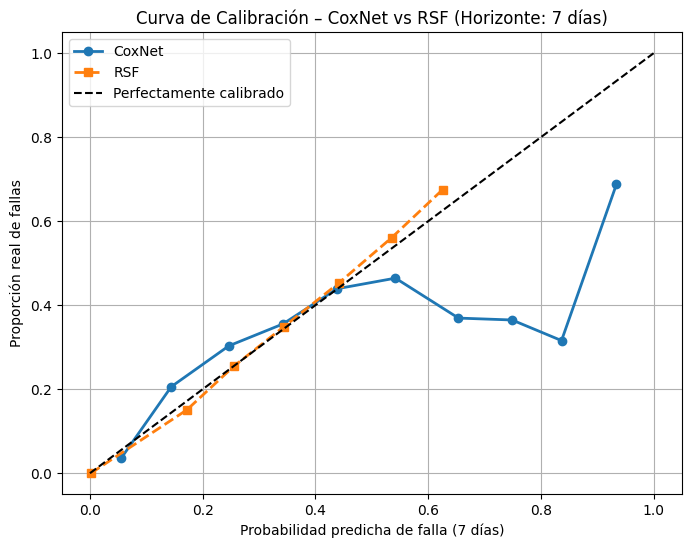

In [35]:
# Definir horizonte de predicción (7 días)
horizonte = 7

# MODELO COXNET
# funciones de supervivencia para CoxNet
surv_funcs_cox = coxnet_model.predict_survival_function(X_test_scaled)

# probabilidad de falla en 7 días
prob_falla_7d_cox = 1 - np.array([fn(horizonte) for fn in surv_funcs_cox])

# MODELO RSF
# funciones de supervivencia para RSF
surv_funcs_rsf = rsf.predict_survival_function(X_test_scaled)

# probabilidad de falla en 7 días
prob_falla_7d_rsf = 1 - np.array([fn(horizonte) for fn in surv_funcs_rsf])

# Variable objetivo observada
eventos = y_test["event"]
tiempos = y_test["time"]
observado_7d = ((eventos == True) & (tiempos <= horizonte)).astype(int)

# Curvas de calibración
fracc_observada_cox, fracc_predicha_cox = calibration_curve(
    observado_7d, prob_falla_7d_cox, n_bins=10, strategy="uniform"
)

fracc_observada_rsf, fracc_predicha_rsf = calibration_curve(
    observado_7d, prob_falla_7d_rsf, n_bins=10, strategy="uniform"
)

# Graficar ambas curvas
plt.figure(figsize=(8,6))
plt.plot(fracc_predicha_cox, fracc_observada_cox, "o-", label="CoxNet", linewidth=2)
plt.plot(fracc_predicha_rsf, fracc_observada_rsf, "s--", label="RSF", linewidth=2)
plt.plot([0,1], [0,1], "k--", label="Perfectamente calibrado")

plt.xlabel("Probabilidad predicha de falla (7 días)")
plt.ylabel("Proporción real de fallas")
plt.title("Curva de Calibración – CoxNet vs RSF (Horizonte: 7 días)")
plt.legend()
plt.grid(True)
plt.show()

##Aplicación Modelo selecionado

In [36]:
HORIZONTE_DIAS = 7
TOP_N = 10

# Predicción de Riesgo

# Predecir las Funciones de Supervivencia S(t) con el modelo RSF
survivor_functions_rsf = rsf.predict_survival_function(X_test_scaled)

# IDENTIFICACIÓN CLAVE: Usar el índice de X_test para buscar el id_movil en df_final
# X_test.index contiene los números de fila
indices_numericos = X_test.index

# Mapear esos índices numéricos al id_movil real en df_final
# Se usa .loc[] en df_final para seleccionar solo las filas que están en el conjunto de prueba
# y extraer la columna 'id_movil'.
ids_moviles_reporte = df_final.loc[indices_numericos, 'id_movil'].values

# Calcular la Probabilidad de Falla (PoF) en el horizonte de 7 días
resultados_riesgo_rsf = []

for i, sf in enumerate(survivor_functions_rsf):
    prob_supervivencia_7d = sf(HORIZONTE_DIAS)
    prob_falla_7d = 1.0 - prob_supervivencia_7d

    resultados_riesgo_rsf.append({
        'id_movil': ids_moviles_reporte[i], # ¡Ahora es el ID real!
        'Prob_Falla_7_Dias': prob_falla_7d
    })

# Generación del TOP N

df_riesgo_rsf = pd.DataFrame(resultados_riesgo_rsf)

# Ordenar por la Probabilidad de Falla
df_riesgo_ordenado_rsf = df_riesgo_rsf.sort_values(
    by='Prob_Falla_7_Dias',
    ascending=False
)

top_riesgo_rsf = df_riesgo_ordenado_rsf.head(TOP_N)

# Presentación de Resultados

print(f"\nBUSES TOP {TOP_N} con MAYOR Probabilidad de Falla (PoF en {HORIZONTE_DIAS} Días):")
print(top_riesgo_rsf.round(4))


BUSES TOP 10 con MAYOR Probabilidad de Falla (PoF en 7 Días):
      id_movil  Prob_Falla_7_Dias
21993   327105             0.6863
12497   504305             0.6645
18532   504233             0.6576
13114   154144             0.6551
2366    454052             0.6542
18155   327105             0.6460
10177   504030             0.6422
7588    704589             0.6406
10292    N0626             0.6401
8868    707355             0.6341


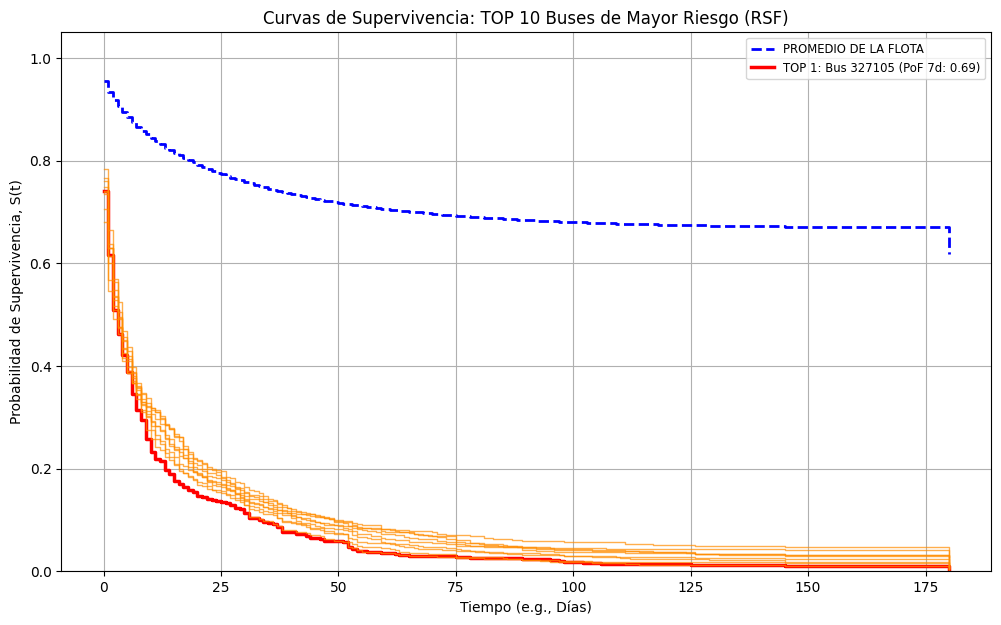

In [39]:
# Extraemos los índices de las filas del TOP 10
indices_top_10 = top_riesgo_rsf.index

plt.figure(figsize=(12, 7))

# Calcular y Graficar Curva de Promedio

# La lista survivor_functions_rsf contiene todas las curvas.
sf_ejemplo = survivor_functions_rsf[0]
time_points = sf_ejemplo.x
survival_prob_mean = np.mean([sf(time_points) for sf in survivor_functions_rsf], axis=0)
plt.step(time_points, survival_prob_mean, where="post", label="PROMEDIO DE LA FLOTA", color='b', linestyle='--', linewidth=2.0)


# Graficar las Curvas de los 10 Buses de MÁXIMO Riesgo

color_riesgo_agrupado = 'darkorange'

# Solo graficamos la primera curva de riesgo con etiqueta para mantener la leyenda limpia,
# y el resto sin etiqueta para no saturar, pero mostrando la agrupación de riesgo.

for i, idx in enumerate(indices_top_10):
    sf = survivor_functions_rsf[idx]

    # Obtenemos los datos para la etiqueta del DataFrame final
    id_movil = df_riesgo_ordenado_rsf.loc[idx, 'id_movil']
    pof = df_riesgo_ordenado_rsf.loc[idx, 'Prob_Falla_7_Dias']

    # La etiqueta solo será para el bus TOP 1, en ROJO.
    label_text = f"TOP 1: Bus {id_movil} (PoF 7d: {pof:.2f})"

    if i == 0:
        # Bus TOP 1 (el más riesgoso) en ROJO
        plt.step(sf.x, sf.y, where="post", label=label_text, color='r', linewidth=2.5, alpha=1.0)
    else:
        # Los otros 9 buses (agrupados) en NARANJA
        plt.step(sf.x, sf.y, where="post", color=color_riesgo_agrupado, linewidth=1.0, alpha=0.7)


plt.title(f"Curvas de Supervivencia: TOP 10 Buses de Mayor Riesgo (RSF)")
plt.xlabel("Tiempo (e.g., Días)")
plt.ylabel("Probabilidad de Supervivencia, S(t)")
plt.legend(loc='upper right', fontsize='small') # Cambiamos la ubicación para evitar colisión con las curvas
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()